# 02 Experiment Analysis

This notebook runs the formal A/B test for the lifecycle campaign case study. The goal is to estimate whether each email treatment caused higher visits, conversions, and customer spend compared with the `No E-Mail` control group.

The primary decision metric is conversion rate. Visit rate and spend per customer are secondary business metrics that help interpret whether a conversion lift also creates meaningful revenue impact.

## Analysis Questions

1. Did either email campaign increase conversion rate compared with the no-email control group?
2. Did either campaign increase visit rate?
3. Did either campaign increase spend per customer?
4. Which treatment has the strongest business case for rollout?

Because this is a randomized experiment, the control group gives us a credible baseline for what would have happened without the campaign.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CONTROL_GROUP, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, RAW_DATA_PATH, FIGURES_DIR
from src.metrics import group_summary, treatment_lift
from src.stat_tests import bootstrap_mean_diff, proportion_diff_ci, two_proportion_z_test

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/.projects/ab-testing')

## Load Analysis Data

The analysis uses the cleaned interim file from the data audit notebook. If that file is missing, this notebook rebuilds the small cleaning step from the raw CSV so the workflow remains reproducible.

In [2]:
clean_path = INTERIM_DATA_DIR / "email_ab_test_clean.csv"

if clean_path.exists():
    df = pd.read_csv(clean_path)
else:
    df = pd.read_csv(RAW_DATA_PATH)
    df["zip_code_clean"] = df["zip_code"].replace({"Surburban": "Suburban"})
    df["is_treatment"] = (df["segment"] != CONTROL_GROUP).astype(int)
    df["campaign_type"] = np.select(
        [
            df["segment"].eq("Mens E-Mail"),
            df["segment"].eq("Womens E-Mail"),
            df["segment"].eq(CONTROL_GROUP),
        ],
        ["Mens", "Womens", "Control"],
        default="Unknown",
    )
    INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(clean_path, index=False)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,zip_code_clean,is_treatment,campaign_type
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000,Suburban,1,Womens
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000,Rural,0,Control
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000,Suburban,1,Womens
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000,Rural,1,Mens
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000,Urban,1,Womens


In [3]:
df.shape

(64000, 15)

## Group-Level Metrics

This table summarizes the raw performance of each experiment group. It is useful for orientation, but the next sections estimate uncertainty and test whether the observed differences are likely to be real campaign effects.

In [4]:
summary = group_summary(df).sort_values("segment").reset_index(drop=True)
summary

,segment,customers,visits,conversions,total_spend,spend_per_customer,visit_rate,conversion_rate,spend_per_converter
0,Mens E-Mail,21307,3894,267,30311.6900,1.4226,0.1828,0.0125,113.5269
1,No E-Mail,21306,2262,122,13908.3300,0.6528,0.1062,0.0057,114.0027
2,Womens E-Mail,21387,3238,189,23038.1100,1.0772,0.1514,0.0088,121.8948


In [5]:
summary.to_csv(PROCESSED_DATA_DIR / "02_group_metric_summary.csv", index=False)

## Metric Definitions

- **Visit rate**: customers who visited the site divided by total customers in the group.
- **Conversion rate**: customers who purchased divided by total customers in the group. This is the primary metric.
- **Spend per customer**: total revenue divided by all customers in the group, including non-purchasers.
- **Spend per converter**: total revenue divided only by customers who purchased.

For a business decision, conversion rate answers whether the campaign changes purchase behavior. Spend per customer answers whether that behavior creates meaningful revenue.

## Lift Versus Control

Lift compares each treatment group with the `No E-Mail` control group. Absolute lift is measured in percentage points or dollars. Relative lift expresses the same effect as a percentage of the control baseline.

In [6]:
lift_summary = treatment_lift(summary, control_group=CONTROL_GROUP).sort_values("segment").reset_index(drop=True)
lift_summary

,segment,control_group,customers,conversion_rate_lift,relative_conversion_lift,incremental_conversions,visit_rate_lift,spend_per_customer_lift,incremental_revenue
0,Mens E-Mail,No E-Mail,21307,0.0068,1.1884,144.9943,0.0766,0.7698,16402.7072
1,Womens E-Mail,No E-Mail,21387,0.0031,0.5433,66.5362,0.0452,0.4244,9076.9041


In [7]:
lift_summary.to_csv(PROCESSED_DATA_DIR / "02_treatment_lift_summary.csv", index=False)

## Proportion Tests: Visit Rate and Conversion Rate

Visit and conversion are binary outcomes, so I compare treatment and control rates with a two-proportion z-test.

For each comparison:

- **Null hypothesis**: the treatment and control rates are equal.
- **Alternative hypothesis**: the treatment and control rates are different.
- **p-value**: how surprising the observed difference would be if the null hypothesis were true.
- **95% confidence interval**: a plausible range for the true treatment lift.

The p-value tells us whether the evidence is statistically strong. The confidence interval tells us the likely size of the effect.

In [8]:
def proportion_test_table(data: pd.DataFrame, metric_col: str, label: str) -> pd.DataFrame:
    control = data.loc[data["segment"].eq(CONTROL_GROUP)]
    n_control = len(control)
    successes_control = int(control[metric_col].sum())
    rows = []

    for treatment_group in sorted(group for group in data["segment"].unique() if group != CONTROL_GROUP):
        treatment = data.loc[data["segment"].eq(treatment_group)]
        n_treatment = len(treatment)
        successes_treatment = int(treatment[metric_col].sum())
        test = two_proportion_z_test(successes_control, n_control, successes_treatment, n_treatment)
        ci = proportion_diff_ci(successes_control, n_control, successes_treatment, n_treatment)

        rows.append(
            {
                "metric": label,
                "comparison": f"{treatment_group} vs {CONTROL_GROUP}",
                "control_group": CONTROL_GROUP,
                "treatment_group": treatment_group,
                "control_n": n_control,
                "treatment_n": n_treatment,
                "control_successes": successes_control,
                "treatment_successes": successes_treatment,
                "control_rate": test["rate_a"],
                "treatment_rate": test["rate_b"],
                "absolute_lift": test["difference"],
                "relative_lift": test["difference"] / test["rate_a"],
                "ci_low": ci["ci_low"],
                "ci_high": ci["ci_high"],
                "z_score": test["z_score"],
                "p_value": test["p_value"],
            }
        )

    return pd.DataFrame(rows)

visit_tests = proportion_test_table(df, "visit", "Visit rate")
conversion_tests = proportion_test_table(df, "conversion", "Conversion rate")
proportion_tests = pd.concat([visit_tests, conversion_tests], ignore_index=True)
proportion_tests

,metric,comparison,control_group,treatment_group,control_n,treatment_n,control_successes,treatment_successes,control_rate,treatment_rate,absolute_lift,relative_lift,ci_low,ci_high,z_score,p_value
0,Visit rate,Mens E-Mail vs No E-Mail,No E-Mail,Mens E-Mail,21306,21307,2262,3894,0.1062,0.1828,0.0766,0.7214,0.0700,0.0832,22.4860,0.0000
1,Visit rate,Womens E-Mail vs No E-Mail,No E-Mail,Womens E-Mail,21306,21387,2262,3238,0.1062,0.1514,0.0452,0.4261,0.0389,0.0516,13.9492,0.0000
2,Conversion rate,Mens E-Mail vs No E-Mail,No E-Mail,Mens E-Mail,21306,21307,122,267,0.0057,0.0125,0.0068,1.1884,0.0050,0.0086,7.3851,0.0000
3,Conversion rate,Womens E-Mail vs No E-Mail,No E-Mail,Womens E-Mail,21306,21387,122,189,0.0057,0.0088,0.0031,0.5433,0.0015,0.0047,3.7796,0.0002


In [9]:
proportion_tests.to_csv(PROCESSED_DATA_DIR / "02_proportion_tests.csv", index=False)

## Spend Analysis

Spend is not a simple yes/no outcome. Most customers spend zero, while a smaller number spend positive amounts. This makes the distribution highly skewed.

For spend per customer, I use a bootstrap confidence interval for the mean difference between treatment and control. Bootstrapping repeatedly resamples the observed customers to estimate how much the mean spend lift could vary. I also include Welch's t-test as a familiar reference, but the business interpretation should focus on the effect size and confidence interval.

In [10]:
def spend_test_table(data: pd.DataFrame, n_bootstrap: int = 5000) -> pd.DataFrame:
    control_spend = data.loc[data["segment"].eq(CONTROL_GROUP), "spend"].to_numpy()
    rows = []

    for i, treatment_group in enumerate(sorted(group for group in data["segment"].unique() if group != CONTROL_GROUP)):
        treatment_spend = data.loc[data["segment"].eq(treatment_group), "spend"].to_numpy()
        boot = bootstrap_mean_diff(
            control_spend,
            treatment_spend,
            n_bootstrap=n_bootstrap,
            confidence=0.95,
            random_state=42 + i,
        )
        t_result = stats.ttest_ind(treatment_spend, control_spend, equal_var=False)
        diff = treatment_spend.mean() - control_spend.mean()

        rows.append(
            {
                "metric": "Spend per customer",
                "comparison": f"{treatment_group} vs {CONTROL_GROUP}",
                "control_group": CONTROL_GROUP,
                "treatment_group": treatment_group,
                "control_n": len(control_spend),
                "treatment_n": len(treatment_spend),
                "control_mean": control_spend.mean(),
                "treatment_mean": treatment_spend.mean(),
                "absolute_lift": diff,
                "relative_lift": diff / control_spend.mean(),
                "ci_low": boot["ci_low"],
                "ci_high": boot["ci_high"],
                "welch_t_stat": t_result.statistic,
                "p_value": t_result.pvalue,
                "estimated_incremental_revenue_in_test_group": diff * len(treatment_spend),
                "estimated_incremental_revenue_per_100k_customers": diff * 100_000,
            }
        )

    return pd.DataFrame(rows)

spend_tests = spend_test_table(df)
spend_tests

,metric,comparison,control_group,treatment_group,control_n,treatment_n,control_mean,treatment_mean,absolute_lift,relative_lift,ci_low,ci_high,welch_t_stat,p_value,estimated_incremental_revenue_in_test_group,estimated_incremental_revenue_per_100k_customers
0,Spend per customer,Mens E-Mail vs No E-Mail,No E-Mail,Mens E-Mail,21306,21307,0.6528,1.4226,0.7698,1.1793,0.4937,1.0610,5.3001,0.0000,16402.7072,76982.7156
1,Spend per customer,Womens E-Mail vs No E-Mail,No E-Mail,Womens E-Mail,21306,21387,0.6528,1.0772,0.4244,0.6502,0.1672,0.6776,3.2564,0.0011,9076.9041,42441.2216


In [11]:
spend_tests.to_csv(PROCESSED_DATA_DIR / "02_spend_tests.csv", index=False)

## Practical Impact Summary

Statistical significance is not enough for a business recommendation. The result also needs to be meaningful in business terms. This table combines the main lift estimates into a practical impact view.

In [12]:
conversion_impact = conversion_tests[[
    "treatment_group",
    "control_rate",
    "treatment_rate",
    "absolute_lift",
    "relative_lift",
    "ci_low",
    "ci_high",
    "p_value",
]].copy()
conversion_impact = conversion_impact.rename(
    columns={
        "control_rate": "control_conversion_rate",
        "treatment_rate": "treatment_conversion_rate",
        "absolute_lift": "conversion_rate_lift",
        "relative_lift": "relative_conversion_lift",
        "ci_low": "conversion_lift_ci_low",
        "ci_high": "conversion_lift_ci_high",
        "p_value": "conversion_p_value",
    }
)

spend_impact = spend_tests[[
    "treatment_group",
    "control_mean",
    "treatment_mean",
    "absolute_lift",
    "relative_lift",
    "ci_low",
    "ci_high",
    "p_value",
    "estimated_incremental_revenue_per_100k_customers",
]].copy()
spend_impact = spend_impact.rename(
    columns={
        "control_mean": "control_spend_per_customer",
        "treatment_mean": "treatment_spend_per_customer",
        "absolute_lift": "spend_per_customer_lift",
        "relative_lift": "relative_spend_lift",
        "ci_low": "spend_lift_ci_low",
        "ci_high": "spend_lift_ci_high",
        "p_value": "spend_p_value",
    }
)

impact_summary = conversion_impact.merge(spend_impact, on="treatment_group")
impact_summary["estimated_incremental_conversions_per_100k_customers"] = impact_summary["conversion_rate_lift"] * 100_000
impact_summary = impact_summary.sort_values("spend_per_customer_lift", ascending=False).reset_index(drop=True)
impact_summary

,treatment_group,control_conversion_rate,treatment_conversion_rate,conversion_rate_lift,relative_conversion_lift,conversion_lift_ci_low,conversion_lift_ci_high,conversion_p_value,control_spend_per_customer,treatment_spend_per_customer,spend_per_customer_lift,relative_spend_lift,spend_lift_ci_low,spend_lift_ci_high,spend_p_value,estimated_incremental_revenue_per_100k_customers,estimated_incremental_conversions_per_100k_customers
0,Mens E-Mail,0.0057,0.0125,0.0068,1.1884,0.0050,0.0086,0.0000,0.6528,1.4226,0.7698,1.1793,0.4937,1.0610,0.0000,76982.7156,680.5007
1,Womens E-Mail,0.0057,0.0088,0.0031,0.5433,0.0015,0.0047,0.0002,0.6528,1.0772,0.4244,0.6502,0.1672,0.6776,0.0011,42441.2216,311.1058


In [13]:
impact_summary.to_csv(PROCESSED_DATA_DIR / "02_practical_impact_summary.csv", index=False)

## Visual Summary

The charts below focus on the metrics that matter most for decision-making: conversion rate, spend per customer, and estimated lift versus the no-email control group.

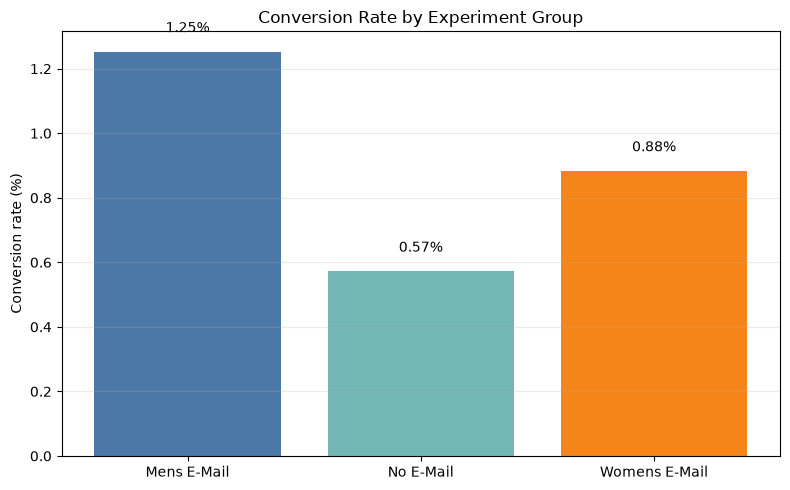

WindowsPath('E:/.projects/ab-testing/reports/figures/02_conversion_rate_by_group.png')

In [14]:
plot_summary = summary.copy()
plot_summary["conversion_rate_pct"] = plot_summary["conversion_rate"] * 100
plot_summary["visit_rate_pct"] = plot_summary["visit_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_summary["segment"], plot_summary["conversion_rate_pct"], color=["#4C78A8", "#72B7B2", "#F58518"])
ax.set_title("Conversion Rate by Experiment Group")
ax.set_ylabel("Conversion rate (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
for i, value in enumerate(plot_summary["conversion_rate_pct"]):
    ax.text(i, value + 0.05, f"{value:.2f}%", ha="center", va="bottom")
plt.tight_layout()
conversion_fig = FIGURES_DIR / "02_conversion_rate_by_group.png"
plt.savefig(conversion_fig, dpi=150)
plt.show()
conversion_fig

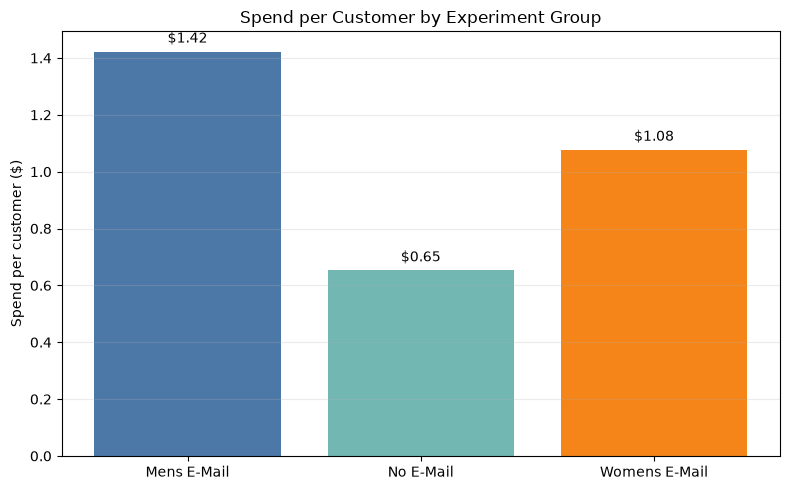

WindowsPath('E:/.projects/ab-testing/reports/figures/02_spend_per_customer_by_group.png')

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["segment"], summary["spend_per_customer"], color=["#4C78A8", "#72B7B2", "#F58518"])
ax.set_title("Spend per Customer by Experiment Group")
ax.set_ylabel("Spend per customer ($)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
for i, value in enumerate(summary["spend_per_customer"]):
    ax.text(i, value + 0.02, f"${value:.2f}", ha="center", va="bottom")
plt.tight_layout()
spend_fig = FIGURES_DIR / "02_spend_per_customer_by_group.png"
plt.savefig(spend_fig, dpi=150)
plt.show()
spend_fig

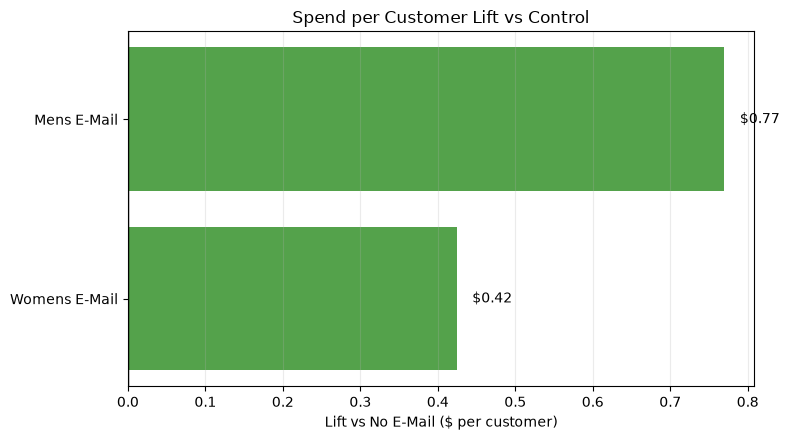

WindowsPath('E:/.projects/ab-testing/reports/figures/02_spend_lift_vs_control.png')

In [16]:
lift_plot = impact_summary.sort_values("spend_per_customer_lift")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(lift_plot["treatment_group"], lift_plot["spend_per_customer_lift"], color="#54A24B")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Spend per Customer Lift vs Control")
ax.set_xlabel("Lift vs No E-Mail ($ per customer)")
ax.grid(axis="x", alpha=0.25)
for i, value in enumerate(lift_plot["spend_per_customer_lift"]):
    ax.text(value + 0.02, i, f"${value:.2f}", va="center")
plt.tight_layout()
lift_fig = FIGURES_DIR / "02_spend_lift_vs_control.png"
plt.savefig(lift_fig, dpi=150)
plt.show()
lift_fig

## Initial Recommendation

At this stage, the strongest recommendation should be based on the total evidence: conversion lift, spend lift, statistical uncertainty, and practical revenue impact. Segment analysis will come next, so this notebook should make a first recommendation without overclaiming that the same strategy is optimal for every customer group.

In [17]:
best = impact_summary.iloc[0]
recommendation_lines = [
    f"Initial recommendation: prioritize `{best['treatment_group']}` for rollout analysis.",
    "",
    "Why:",
    f"- Conversion rate lift vs control: {best['conversion_rate_lift']:.4%} ({best['relative_conversion_lift']:.1%} relative lift)",
    f"- Conversion p-value: {best['conversion_p_value']:.4g}",
    f"- Spend per customer lift vs control: ${best['spend_per_customer_lift']:.2f} ({best['relative_spend_lift']:.1%} relative lift)",
    f"- Estimated incremental revenue per 100,000 targeted customers: ${best['estimated_incremental_revenue_per_100k_customers']:,.0f}",
    "",
    "Decision note: this is a strong overall result, but the next notebook should check segment-level effects before recommending a final targeting strategy.",
]
print("\n".join(recommendation_lines))

Initial recommendation: prioritize `Mens E-Mail` for rollout analysis.

Why:
- Conversion rate lift vs control: 0.6805% (118.8% relative lift)
- Conversion p-value: 1.523e-13
- Spend per customer lift vs control: $0.77 (117.9% relative lift)
- Estimated incremental revenue per 100,000 targeted customers: $76,983

Decision note: this is a strong overall result, but the next notebook should check segment-level effects before recommending a final targeting strategy.


## Notebook Outputs

This notebook writes the following reusable outputs:

- `data/processed/02_group_metric_summary.csv`
- `data/processed/02_treatment_lift_summary.csv`
- `data/processed/02_proportion_tests.csv`
- `data/processed/02_spend_tests.csv`
- `data/processed/02_practical_impact_summary.csv`
- `reports/figures/02_conversion_rate_by_group.png`
- `reports/figures/02_spend_per_customer_by_group.png`
- `reports/figures/02_spend_lift_vs_control.png`

Next notebook: `03_segment_uplift_analysis.ipynb`.